In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer,KNNImputer

url="https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df=pd.read_csv(url)

print(df.head())
print("\nMissing values count:\n", df.isnull().sum())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Missing values count:
 longitude               0
latitude                0

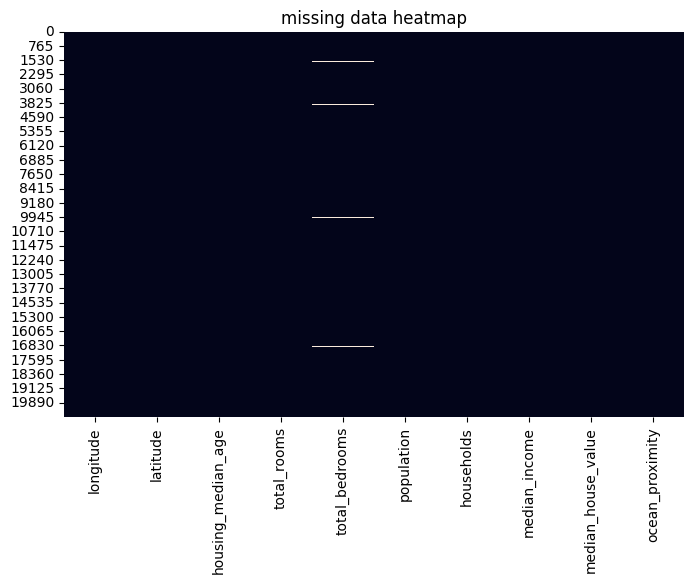

In [2]:
#visualize missing data
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(),cbar=False)
plt.title("missing data heatmap")
plt.show()

In [3]:
#drop misssing data
df.drop_rows=df.dropna()
df.drop_cols=df.dropna(axis=1)
print(df.drop_rows)
print(df.drop_cols)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  households  median_income  media

/tmp/ipython-input-4269529495.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.drop_rows=df.dropna()
/tmp/ipython-input-4269529495.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.drop_cols=df.dropna(axis=1)


In [4]:
#fill missing datawith constant

df.constant=df.copy()
df.constant['total_bedrooms']=df.constant['total_bedrooms'].fillna(0)


/tmp/ipython-input-4130724687.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.constant=df.copy()


In [6]:
#fill with mean median mode

df.mean=df.copy()
df.mean['total_bedrooms']=df.mean['total_bedrooms'].fillna(df.mean['total_bedrooms'].mean())
df.median=df.copy()
df.median['total bedrooms']=df.median['total_bedrooms'].fillna(df.median['total_bedrooms'].median())
df.mode=df.copy()
df.mode['ocean_proximity']=df.mode['ocean_proximity'].fillna(df.mode['ocean_proximity'].mode()[0])



In [7]:
#forward &backward fill

df.ffill=df.fillna(method='ffill')
df.bfill=df.fillna(method='bfill')

/tmp/ipython-input-3144760023.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.ffill=df.fillna(method='ffill')
/tmp/ipython-input-3144760023.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.bfill=df.fillna(method='bfill')


In [9]:
#simpleIMPUTER
simple_imp=SimpleImputer(strategy='median')
df_simple=df.copy()
df_simple['total_bedrooms']=simple_imp.fit_transform(df[['total_bedrooms']])

In [10]:
#using KNNImputer
df_knn=df.copy()

#only numeric columns for knn
numeric_df=df_knn.select_dtypes(include=[np.number])

knn=KNNImputer(n_neighbors=3)
knn_result=knn.fit_transform(numeric_df)
df_knn[numeric_df.columns]=knn_result

print("\n =====knn imputed sample===")
print(df_knn.head())



 =====knn imputed sample===
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
